This version train AlexNet with images cropped and results are:

epochs = 100

Accuracy on training data:  83.0

Accuracy on testing data:  80.0

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import torch
path = 'drive/MyDrive/datasets/OHULGender/'
# Device configuration
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

In [ ]:
import torch
import torchvision
import torch.nn.functional as F
import torch.optim as optim
import torch.nn as nn
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

In [ ]:
batch_size = 20

train_dir = path + 'train_gender'
test_dir = path + 'test_gender'
# VGG-16 takes 224x224 images as input, so we resize all of them
transforms = transforms.Compose([
  transforms.Resize(224),
  transforms.RandomCrop(224),
  transforms.RandomRotation(30),
  transforms.ToTensor(),  
  transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])]) 


train_dataset = datasets.ImageFolder(root=train_dir, transform=transforms)
test_dataset = datasets.ImageFolder(root=test_dir, transform=transforms)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=True)

In [ ]:
print(train_loader.dataset)
print(test_loader.dataset)

Dataset ImageFolder
    Number of datapoints: 1971
    Root location: drive/MyDrive/datasets/OHULGender/train_gender
    StandardTransform
Transform: Compose(
               Resize(size=224, interpolation=bilinear)
               RandomCrop(size=(224, 224), padding=None)
               RandomRotation(degrees=[-30.0, 30.0], interpolation=nearest, expand=False, fill=0)
               ToTensor()
               Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
           )
Dataset ImageFolder
    Number of datapoints: 256
    Root location: drive/MyDrive/datasets/OHULGender/test_gender
    StandardTransform
Transform: Compose(
               Resize(size=224, interpolation=bilinear)
               RandomCrop(size=(224, 224), padding=None)
               RandomRotation(degrees=[-30.0, 30.0], interpolation=nearest, expand=False, fill=0)
               ToTensor()
               Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
           )


In [ ]:
classes = test_dataset.classes
print(classes)

import numpy as np

def imshow(image):
    image = image.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    image = std * image + mean
    image = np.clip(image, 0, 1)
    plt.imshow(image)

['female', 'male']


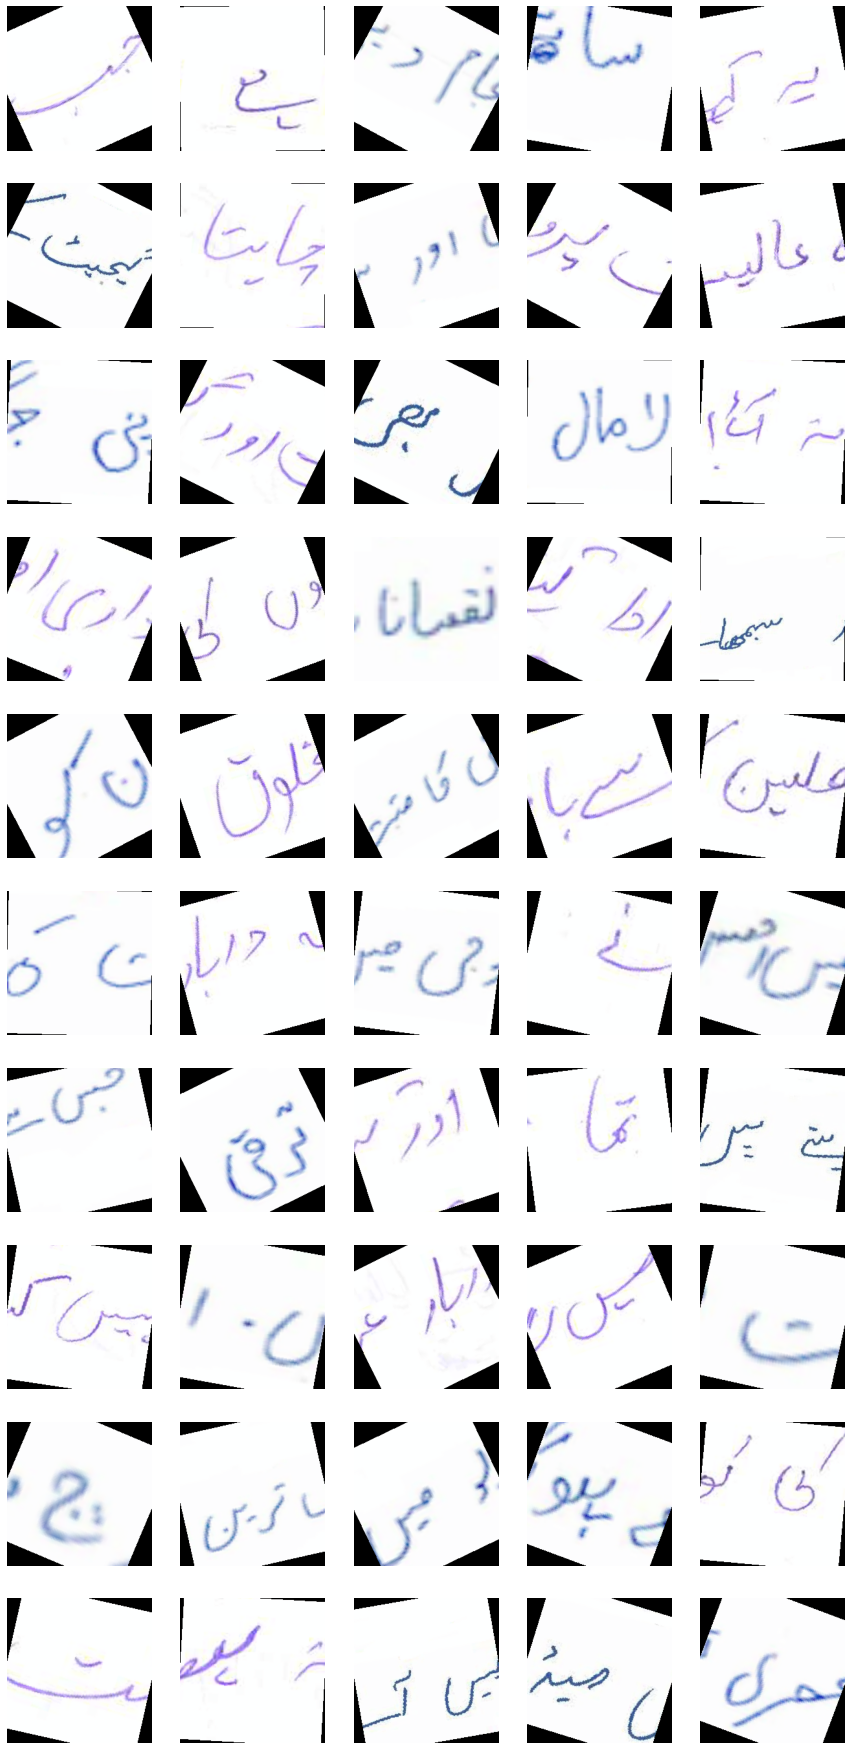

In [ ]:
test_loader_plot = DataLoader(test_dataset, batch_size=50, shuffle=True)

def visualize_results():
    fig = plt.figure(figsize=(15, 32))
    for inputs, targets in test_loader_plot:
      inputs = inputs.to(device)
      targets = targets.to(device)

      for j in range(50):
          ax = plt.subplot(10, 5, j+1)
          ax.axis('off')
          imshow(inputs.cpu().data[j])
      break

visualize_results()

In [ ]:
mode = 'AlexNet' #AlexNet, VGG16, GoogleNet, ResNet18, DenseNet
#print(torch.__version__)

In [ ]:
# Load the pretrained model from pytorch
if mode == 'VGG16':
  vgg16 = models.vgg16(pretrained=True)
  # print out the model structure
  print(vgg16)
elif mode == 'AlexNet':
  alexNet = models.alexnet(pretrained=True)
  # print out the model structure
  print(alexNet)
elif mode == 'GoogleNet':
  googleNet = models.googleNet(pretrained=True)
  # print out the model structure
  print(googleNet)
elif mode == 'ResNet18':
  resNet = models.resnet18(pretrained=True)
  # print out the model structure
  print(resNet)
elif mode == 'DenseNet':
  denseNet = models.densenet161(pretrained=True)
  # print out the model structure
  print(denseNet)




Downloading: "https://download.pytorch.org/models/alexnet-owt-4df8aa71.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-4df8aa71.pth



AlexNet(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 192, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(192, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (avgpool): AdaptiveAvgPool2d(output_size=(6, 6))
  (classifier): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=9216, out_features=4096, bias=True)


In [ ]:
if mode == 'VGG16':
  print(vgg16.classifier[6].in_features) 
  print(vgg16.classifier[6].out_features)
elif mode == 'AlexNet':
  print(alexNet.classifier[6].in_features) 
  print(alexNet.classifier[6].out_features)
elif mode == 'GoogleNet':
  print(googleNet.fc.in_features) 
  print(googleNet.fc.out_features)
elif mode == 'ResNet18':
  print(resNet.fc.in_features) 
  print(resNet.fc.out_features)
elif mode == 'DenseNet':
  print(denseNet.classifier.in_features) 
  print(denseNet.classifier.out_features)



4096
1000


In [ ]:
# Freeze training for all "features" layers
if mode == 'VGG16':
  for param in vgg16.features.parameters():
    param.requires_grad = False
elif mode == 'AlexNet':
  for param in alexNet.features.parameters():
    param.requires_grad = False
elif mode == 'GoogleNet':
  for param in googleNet.parameters():
    param.requires_grad = False
elif mode == 'ResNet18':
  for param in resNet.parameters():
    param.requires_grad = False
elif mode == 'DenseNet':
  for param in denseNet.features.parameters():
    param.requires_grad = False



In [ ]:
import torch.nn as nn

if mode == 'VGG16':
  last_layer_inputs = vgg16.classifier[6].in_features
  last_layer = nn.Linear(last_layer_inputs, len(classes))
  vgg16.classifier[6] = last_layer

  # after completing your model, if GPU is available, move the model to GPU
  vgg16.to(device)

elif mode == 'AlexNet':
  last_layer_inputs = alexNet.classifier[6].in_features
  last_layer = nn.Linear(last_layer_inputs, len(classes))
  alexNet.classifier[6] = last_layer

  # after completing your model, if GPU is available, move the model to GPU
  alexNet.to(device)

elif mode == 'GoogleNet':
  last_layer_inputs = googleNet.fc.in_features
  last_layer = nn.Linear(last_layer_inputs, len(classes))
  googleNet.fc = last_layer

  # after completing your model, if GPU is available, move the model to GPU
  googleNet.to(device)

elif mode == 'ResNet18':
  last_layer_inputs = resNet.fc.in_features
  last_layer = nn.Linear(last_layer_inputs, len(classes))
  resNet.fc = last_layer

  # after completing your model, if GPU is available, move the model to GPU
  resNet.to(device)

elif mode == 'DenseNet':
  last_layer_inputs = denseNet.classifier.in_features
  last_layer = nn.Linear(last_layer_inputs, len(classes))
  denseNet.classifier = last_layer

  # after completing your model, if GPU is available, move the model to GPU
  denseNet.to(device)



In [ ]:
if mode == 'VGG16':
  print(vgg16.classifier[6].in_features) 
  print(vgg16.classifier[6].out_features)
elif mode == 'AlexNet':
  print(alexNet.classifier[6].in_features) 
  print(alexNet.classifier[6].out_features)
elif mode == 'GoogleNet':
  print(googleNet.fc.in_features) 
  print(googleNet.fc.out_features)
elif mode == 'ResNet18':
  print(resNet.fc.in_features) 
  print(resNet.fc.out_features)
elif mode == 'DenseNet':
  print(denseNet.classifier.in_features) 
  print(denseNet.classifier.out_features)


4096
2


In [ ]:
criterion = nn.CrossEntropyLoss()

if mode == 'VGG16':
  optimizer = optim.Adam(vgg16.classifier.parameters(), lr=0.001)
elif mode == 'AlexNet':
  optimizer = optim.RMSprop(alexNet.classifier.parameters(), lr=0.001)
elif mode == 'GoogleNet':
  optimizer = optim.SGD(googleNet.fc.parameters(), lr=0.001)
elif mode == 'ResNet18':
  optimizer = optim.RMSprop(resNet.fc.parameters(), lr=0.001)
elif mode == 'DenseNet':
  optimizer = optim.Adam(denseNet.classifier.parameters(), lr=0.001)



In [ ]:
train_loss = []

def train(epochs):
  
  if mode == 'VGG16':
    vgg16.train()
  elif mode == 'AlexNet':
    alexNet.train()
  elif mode == 'GoogleNet':
    googleNet.train()
  elif mode == 'ResNet18':
    resNet.train()
  elif mode == 'DenseNet':
    denseNet.train()
    
  for epoch in range(epochs):
    running_loss = 0.
    n_samples = 0
      
    for idx, (inputs, targets) in enumerate(train_loader):
        inputs = inputs.to(device)
        targets = targets.to(device) 
      
        n_samples += inputs.size()[0]

        if mode == 'VGG16':
          outputs = vgg16(inputs)
        elif mode == 'AlexNet':
          outputs = alexNet(inputs)
        elif mode == 'GoogleNet':
          outputs = googleNet(inputs)
        elif mode == 'ResNet18':
          outputs = resNet(inputs)
        elif mode == 'DenseNet':
          outputs = denseNet(inputs)
          
        loss = criterion(outputs, targets)
        running_loss += loss.detach().item() / inputs.size()[0]
          
        optimizer.zero_grad() 
        loss.backward()
        optimizer.step()

    train_loss.append(running_loss / n_samples)      
    
    print("Epoch: {} | training loss: {} ".format(epoch + 1, train_loss[-1])) 

  return train_loss
    
train_loss = train(100)  

Epoch: 1 | training loss: 0.10773550731483339 
Epoch: 2 | training loss: 0.0016567700016345153 
Epoch: 3 | training loss: 0.0015862285091529382 
Epoch: 4 | training loss: 0.0015567639906117964 
Epoch: 5 | training loss: 0.001583170845446883 
Epoch: 6 | training loss: 0.0015081630715155568 
Epoch: 7 | training loss: 0.0015411460498185251 
Epoch: 8 | training loss: 0.0015027422890067797 
Epoch: 9 | training loss: 0.001506698678713829 
Epoch: 10 | training loss: 0.0015219907538405121 
Epoch: 11 | training loss: 0.0015200019407154673 
Epoch: 12 | training loss: 0.001454466393301723 
Epoch: 13 | training loss: 0.0015338054577432587 
Epoch: 14 | training loss: 0.0014689532961662192 
Epoch: 15 | training loss: 0.001425104346652954 
Epoch: 16 | training loss: 0.0013916350035483558 
Epoch: 17 | training loss: 0.0013652149803850917 
Epoch: 18 | training loss: 0.0014846478113058799 
Epoch: 19 | training loss: 0.0013387309085863125 
Epoch: 20 | training loss: 0.001374894729850862 
Epoch: 21 | trai

In [ ]:
import numpy as np

test_loss = 0
class_correct = list(0. for i in range(3))
class_total = list(0. for i in range(3))

if mode == 'VGG16':
  vgg16.eval()
elif mode == 'AlexNet':
  alexNet.eval()
elif mode == 'GoogleNet':
  googleNet.eval()
elif mode == 'ResNet18':
  resNet.eval()
elif mode == 'DenseNet':
  denseNet.eval()

total = 0
correct = 0
with torch.no_grad():
    for data in train_loader:
        inputs, targets= data
        inputs = inputs.to(device)
        targets = targets.to(device)

        if mode == 'VGG16':
          outputs = vgg16(inputs)
        elif mode == 'AlexNet':
          outputs = alexNet(inputs)
        elif mode == 'GoogleNet':
          outputs = googleNet(inputs)
        elif mode == 'ResNet18':
          outputs = resNet(inputs)
        elif mode == 'DenseNet':
          outputs = denseNet(inputs)

        _, predicted = torch.max(outputs, 1)
        correct += (predicted == targets).sum().item() 
        total += inputs.size()[0] 
        
print("Accuracy on training data: ", round(correct/total, 2)*100)

total = 0
correct = 0
with torch.no_grad():
    for data in test_loader:
        inputs, targets= data
        inputs = inputs.to(device)
        targets = targets.to(device)
        
        if mode == 'VGG16':
          outputs = vgg16(inputs)
        elif mode == 'AlexNet':
          outputs = alexNet(inputs)
        elif mode == 'GoogleNet':
          outputs = googleNet(inputs)
        elif mode == 'ResNet18':
          outputs = resNet(inputs)
        elif mode == 'DenseNet':
          outputs = denseNet(inputs)

        _, predicted = torch.max(outputs, 1)
        correct += (predicted == targets).sum().item() 
        total += inputs.size()[0] 
        
print("Accuracy on testing data: ", round(correct/total, 2)*100)



Accuracy on training data:  83.0
Accuracy on testing data:  80.0


Accuracy on testing data:  80.0


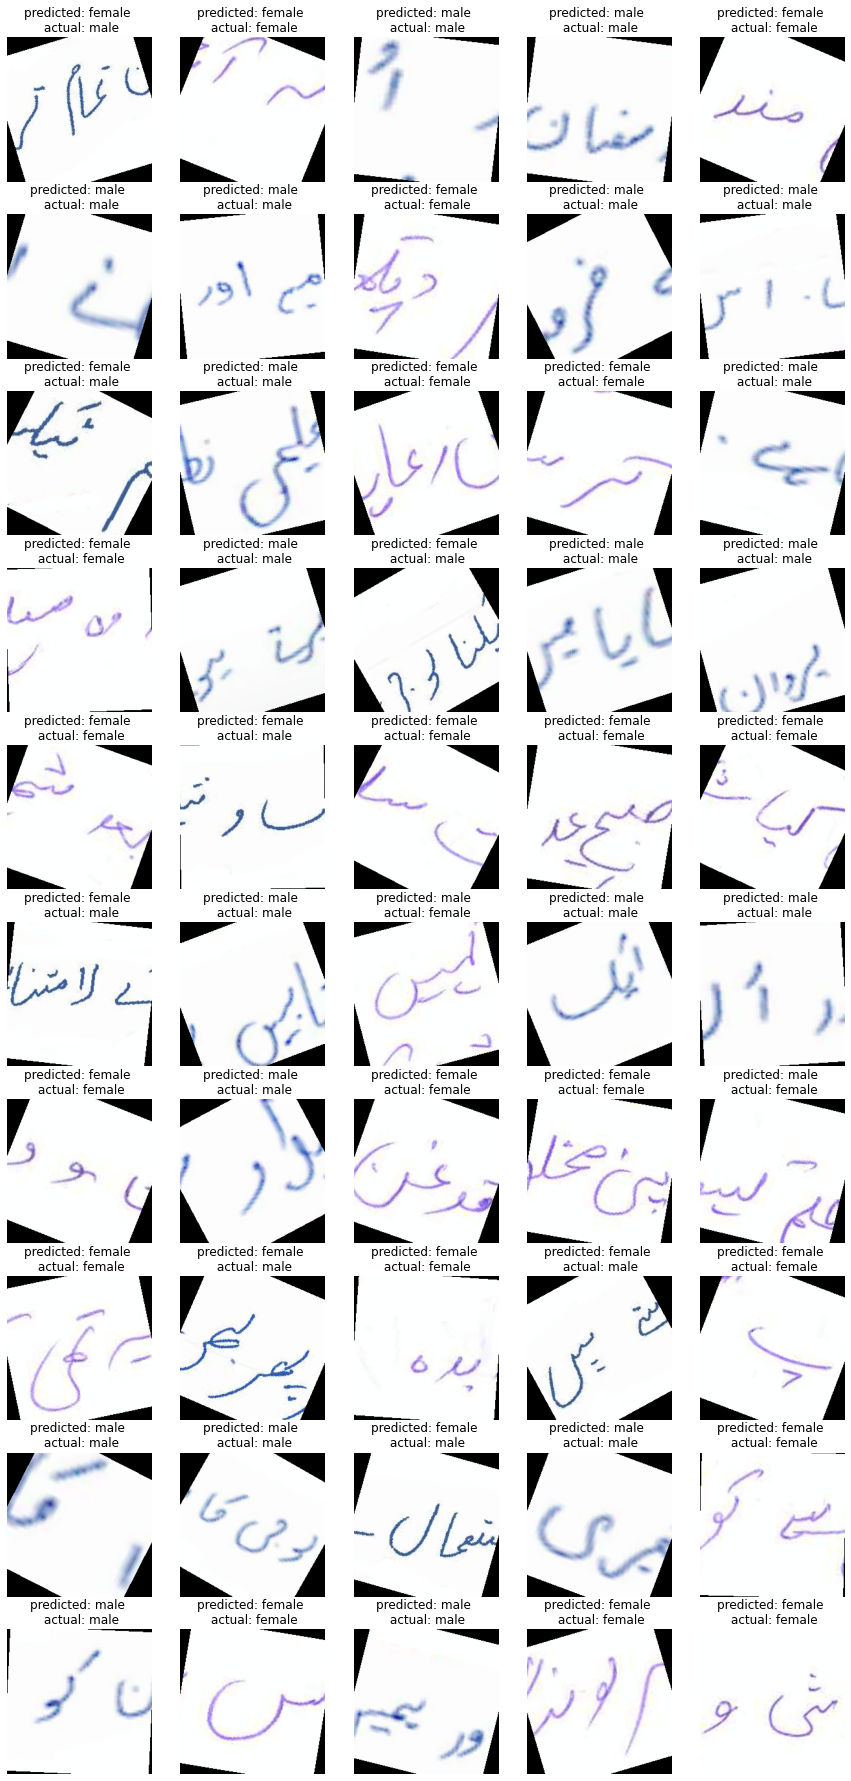

In [ ]:
total = 0
correct = 0
fig = plt.figure(figsize=(15, 32))
class_names = test_dataset.classes
with torch.no_grad():
    for data in test_loader_plot:
        inputs, targets= data
        inputs = inputs.to(device)
        targets = targets.to(device)
        
        if mode == 'VGG16':
          outputs = vgg16(inputs)
        elif mode == 'AlexNet':
          outputs = alexNet(inputs)
        elif mode == 'GoogleNet':
          outputs = googleNet(inputs)
        elif mode == 'ResNet18':
          outputs = resNet(inputs)
        elif mode == 'DenseNet':
          outputs = denseNet(inputs)

        _, predicted = torch.max(outputs, 1)
        correct += (predicted == targets).sum().item() 
        total += inputs.size()[0] 

        for j in range(50):
          ax = plt.subplot(10, 5, j+1)
          ax.axis('off')       
          ax.set_title('predicted: {} \n actual: {}'.format(class_names[predicted[j]], class_names[targets[j]]))
          imshow(inputs.cpu().data[j])

        break
        
print("Accuracy on testing data: ", round(correct/total, 2)*100)